In [1]:
!pip install ultralytics opencv-python tqdm --quiet

In [2]:
import os
import shutil
import random
from tqdm import tqdm

ANIMALS_PATH = "/kaggle/input/datasets/almazkomath/animals/animals"
VEHICLES_PATH = "/kaggle/input/datasets/almazkomath/vehicles"

OUT_PATH = "/kaggle/working/dataset"

In [4]:
for split in ["train", "val"]:
    os.makedirs(f"{OUT_PATH}/images/{split}", exist_ok=True)
    os.makedirs(f"{OUT_PATH}/labels/{split}", exist_ok=True)

In [5]:
class_list = []
class_map = {}

# Animals
for animal in sorted(os.listdir(ANIMALS_PATH)):
    if os.path.isdir(os.path.join(ANIMALS_PATH, animal)):
        class_map[animal] = len(class_list)
        class_list.append(animal)

print("Animal classes:", class_list)

Animal classes: ['Bear', 'Brown bear', 'Bull', 'Camel', 'Cattle', 'Cheetah', 'Chicken', 'Crocodile', 'Deer', 'Duck', 'Eagle', 'Elephant', 'Fox', 'Frog', 'Giraffe', 'Goat', 'Goldfish', 'Goose', 'Hamster', 'Hedgehog', 'Hippopotamus', 'Horse', 'Jaguar', 'Kangaroo', 'Koala', 'Leopard', 'Lion', 'Lynx', 'Monkey', 'Mule', 'Ostrich', 'Panda', 'Penguin', 'Pig', 'Polar bear', 'Rabbit', 'Raccoon', 'Red panda', 'Rhinoceros', 'Sheep', 'Snake', 'Squirrel', 'Swan', 'Tiger', 'Tortoise', 'Turkey', 'Zebra']


In [6]:
def process_animals():
    valid_ext = (".jpg", ".jpeg", ".png")

    for animal in os.listdir(ANIMALS_PATH):
        folder = os.path.join(ANIMALS_PATH, animal)

        if not os.path.isdir(folder):
            continue

        class_id = class_map[animal]

        for file in tqdm(os.listdir(folder)):
            src = os.path.join(folder, file)

            if os.path.isdir(src):
                continue

            if not file.lower().endswith(valid_ext):
                continue

            split = "train" if random.random() < 0.8 else "val"

            new_name = f"{animal}_{file}"
            dst_img = f"{OUT_PATH}/images/{split}/{new_name}"
            dst_lbl = f"{OUT_PATH}/labels/{split}/{new_name.rsplit('.',1)[0]}.txt"

            shutil.copy(src, dst_img)

            with open(dst_lbl, "w") as f:
                f.write(f"{class_id} 0.5 0.5 0.6 0.6\n")

process_animals()

100%|██████████| 44/44 [00:00<00:00, 369.02it/s]


In [7]:
def process_vehicles():
    img_path = os.path.join(VEHICLES_PATH, "train/images")
    lbl_path = os.path.join(VEHICLES_PATH, "train/labels")

    valid_ext = (".jpg", ".jpeg", ".png")

    unique_ids = set()

    for file in os.listdir(lbl_path):
        with open(os.path.join(lbl_path, file)) as f:
            for line in f:
                unique_ids.add(int(line.split()[0]))

    unique_ids = sorted(unique_ids)
    print("Vehicle class IDs:", unique_ids)

    # Map to names
    vehicle_id_map = {i: f"vehicle_{i}" for i in unique_ids}

    # global class list
    for name in vehicle_id_map.values():
        class_map[name] = len(class_list)
        class_list.append(name)

    # Process images
    for img in tqdm(os.listdir(img_path)):
        if not img.lower().endswith(valid_ext):
            continue

        src_img = os.path.join(img_path, img)
        src_lbl = os.path.join(lbl_path, img.rsplit(".",1)[0] + ".txt")

        if not os.path.exists(src_lbl):
            continue

        split = "train" if random.random() < 0.8 else "val"

        dst_img = f"{OUT_PATH}/images/{split}/veh_{img}"
        dst_lbl = f"{OUT_PATH}/labels/{split}/veh_{img.rsplit('.',1)[0]}.txt"

        shutil.copy(src_img, dst_img)

        new_lines = []

        with open(src_lbl) as f:
            for line in f:
                parts = line.strip().split()

                old_id = int(parts[0])
                new_id = class_map[vehicle_id_map[old_id]]

                parts[0] = str(new_id)
                new_lines.append(" ".join(parts))

        with open(dst_lbl, "w") as f:
            f.write("\n".join(new_lines))

process_vehicles()

Vehicle class IDs: [0, 1, 2, 3, 4, 5]


100%|██████████| 9211/9211 [00:31<00:00, 290.98it/s]


In [8]:
yaml_text = f"""
path: {OUT_PATH}

train: images/train
val: images/val

nc: {len(class_list)}
names: {class_list}
"""

with open(f"{OUT_PATH}/data.yaml", "w") as f:
    f.write(yaml_text)

print("Final classes:", class_list)

Final classes: ['Bear', 'Brown bear', 'Bull', 'Camel', 'Cattle', 'Cheetah', 'Chicken', 'Crocodile', 'Deer', 'Duck', 'Eagle', 'Elephant', 'Fox', 'Frog', 'Giraffe', 'Goat', 'Goldfish', 'Goose', 'Hamster', 'Hedgehog', 'Hippopotamus', 'Horse', 'Jaguar', 'Kangaroo', 'Koala', 'Leopard', 'Lion', 'Lynx', 'Monkey', 'Mule', 'Ostrich', 'Panda', 'Penguin', 'Pig', 'Polar bear', 'Rabbit', 'Raccoon', 'Red panda', 'Rhinoceros', 'Sheep', 'Snake', 'Squirrel', 'Swan', 'Tiger', 'Tortoise', 'Turkey', 'Zebra', 'vehicle_0', 'vehicle_1', 'vehicle_2', 'vehicle_3', 'vehicle_4', 'vehicle_5']


In [9]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

model.train(
    data=f"{OUT_PATH}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    augment=True
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7979f0256a50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.0

In [ ]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train-3/weights/best.pt")

results = model.predict(
    source="/kaggle/working/dataset/images/val",
    conf=0.1,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/5039 /kaggle/working/dataset/images/val/Bear_0df78ee76bafd3a9.jpg: 480x640 1 Bear, 56.7ms
image 2/5039 /kaggle/working/dataset/images/val/Bear_0f899aca6d0fb6e1.jpg: 480x640 1 Bear, 8.2ms
image 3/5039 /kaggle/working/dataset/images/val/Bear_1cca48c57103a42c.jpg: 512x640 1 Red panda, 54.9ms
image 4/5039 /kaggle/working/dataset/images/val/Bear_23d1d39d81d411da.jpg: 640x640 1 Snake, 8.5ms
image 5/5039 /kaggle/working/dataset/images/val/Bear_322e901e9

In [13]:
from ultralytics import YOLO

metrics = model.val()

print(metrics)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1742.4±767.6 MB/s, size: 229.1 KB)
val: Scanning /kaggle/working/dataset/labels/val.cache... 5038 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5039/5039 1.4Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 315/315 7.6it/s 41.5s0.2ss
                   all       5039      22308      0.818      0.885      0.901      0.861
                  Bear         23         23      0.535      0.826      0.789      0.789
            Brown bear         16         16      0.599          1      0.956      0.956
                  Bull         38         38      0.545       0.85      0.715      0.715
                 Camel         15         15      0.859          1      0.995      0.995
                Cattle         85         85      0.692      0.941      0.895      0.885
               Cheetah  

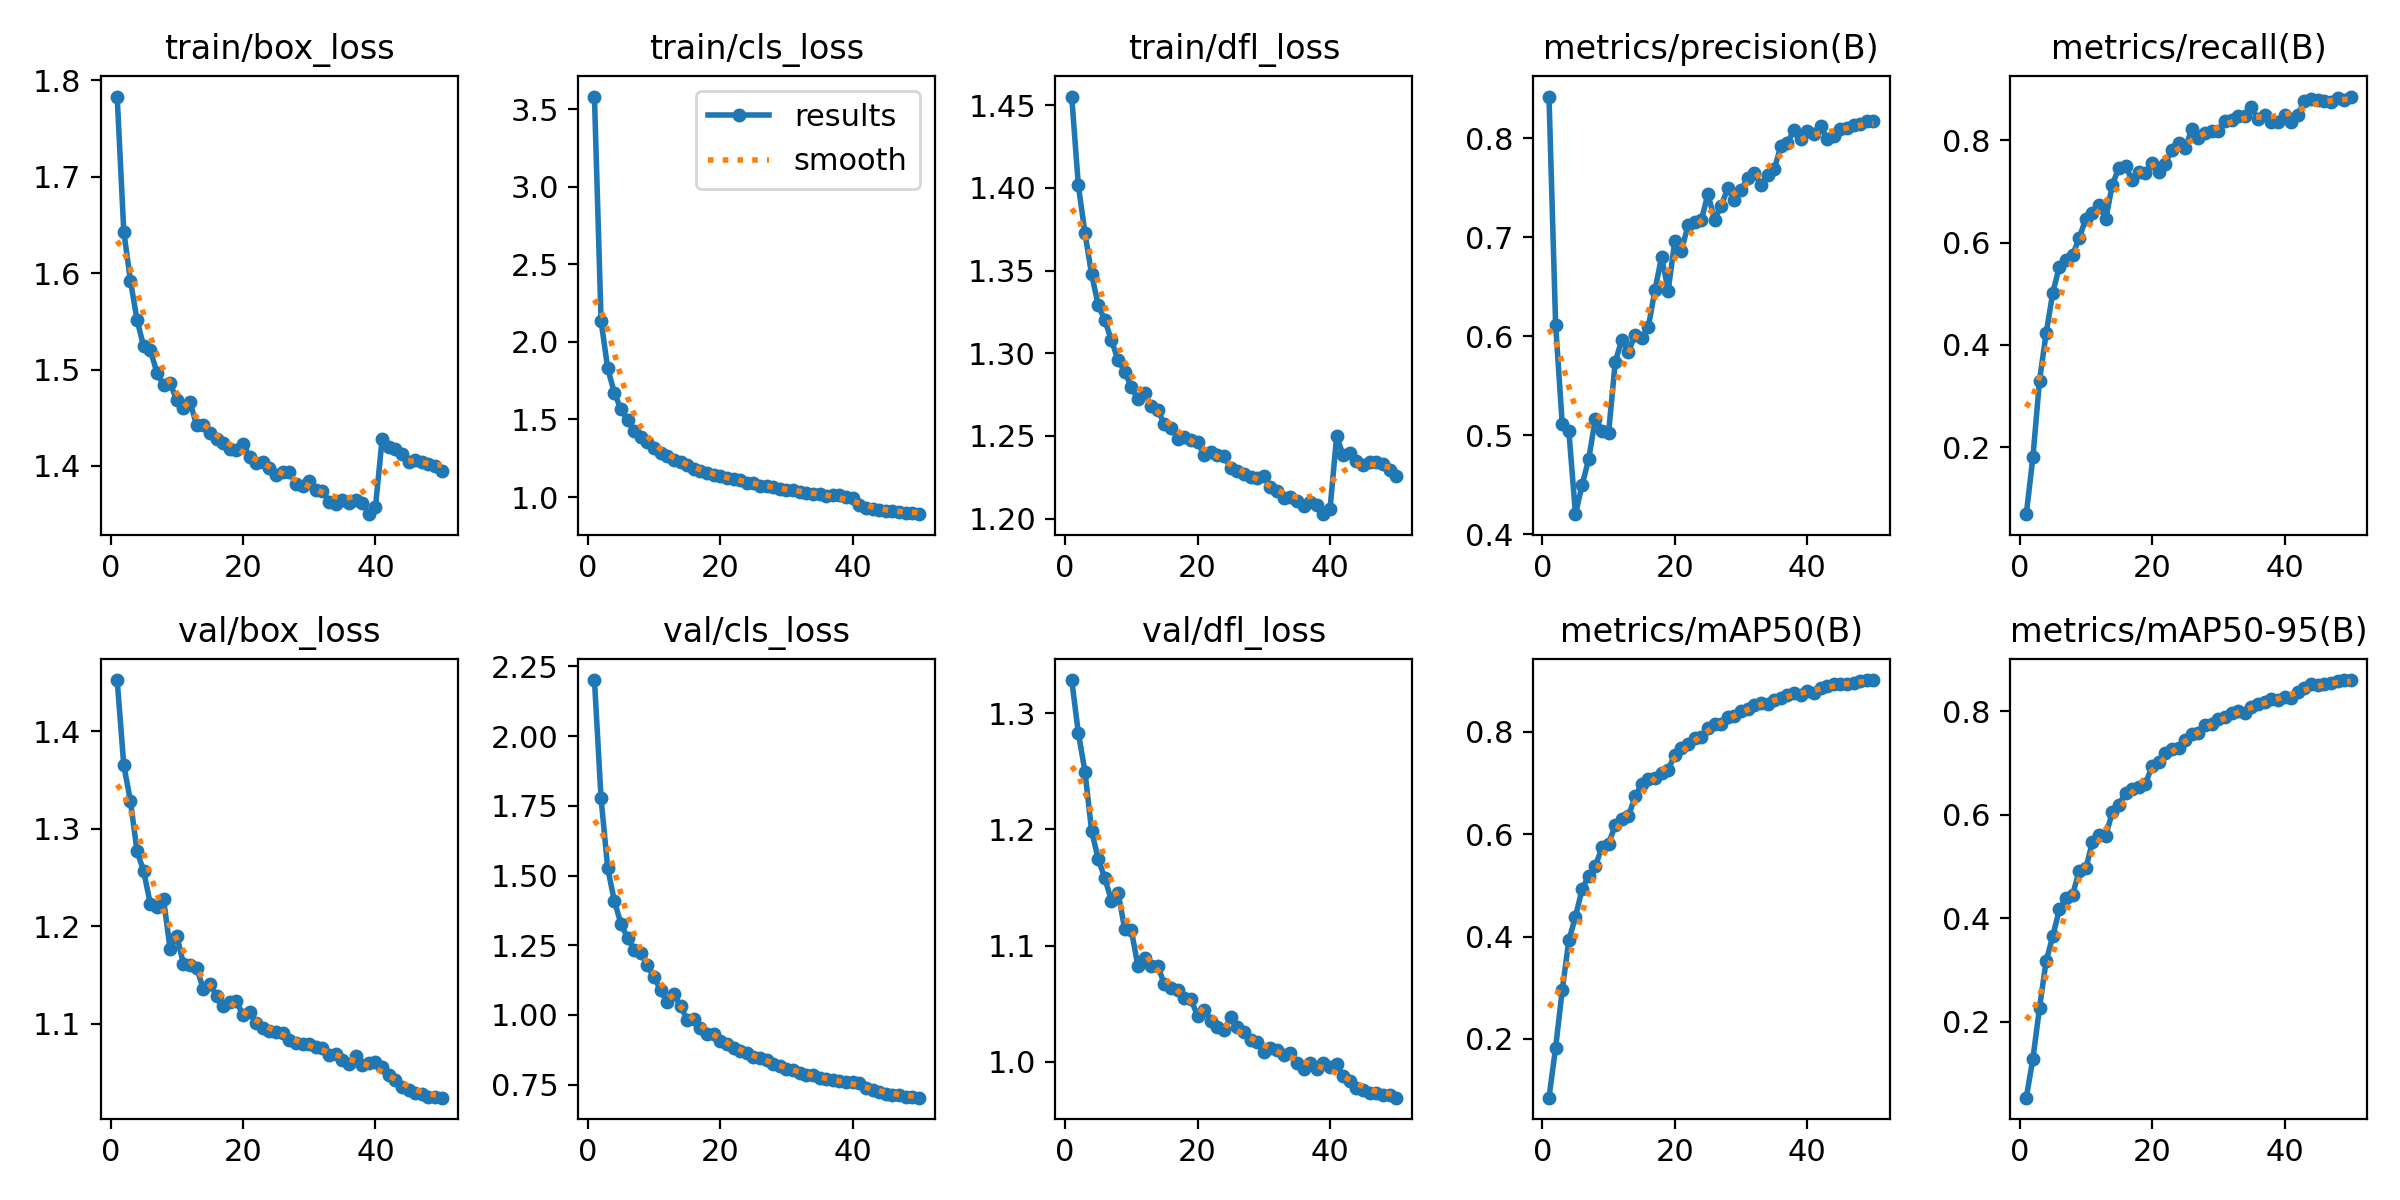

In [14]:
from IPython.display import Image

Image("/kaggle/working/runs/detect/train-3/results.png") 